# Classificando Pneumonia


Adaptado do [exemplo do Keras](https://keras.io/examples/vision/xray_classification_with_tpus).

Nesse notebook vamos criar um modelo usando camadas CNN para classificar radiografias de pulmões como: pneumonia ou normal.

A base de dados é adaptada da
[*Cell*](https://www.cell.com/cell/fulltext/S0092-8674(18)30154-5), já com algum preprocessamente feito (separação entre treino, validação e teste). O link para baixar a base de dados está [aqui](https://1drv.ms/u/s!AvNLrGzXNJrem-90eDNZdzHxcCh4AQ?e=iHEVio).

- Exemplos de radiografias normais (base treino): `1349`
- Exemplos de radiografias com pneumonia (base treino): `3883`

Baixe o arquivo compactado e rode o comando abaixo para descompactar as bases de dados.

In [1]:
!unzip datasets.zip

## Configuração inicial


In [ ]:
import re
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

Parâmetros da base de dados:

In [ ]:
BATCH_SIZE = 16
IMAGE_SIZE = [180, 180]
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

In [ ]:
train_ds = tf.data.Dataset.load("train_ds")
val_ds = tf.data.Dataset.load("val_ds")
test_ds = tf.data.Dataset.load("test_ds")

Na classificação, `1` ou `True` representa
pneumonia e `0` ou `False` representa normal.

## Exemplo de imagens

Vamos deixar a imagem em memória (não faça isso para bases grandes!) para acelerar a iteração.

In [ ]:
def prepare_for_training(ds, cache=True):
    # This is a small dataset, only load it once, and keep it in memory.
    # use `.cache(filename)` to cache preprocessing work for datasets that don't
    # fit in memory.
    if cache:
        if isinstance(cache, str):
            ds = ds.cache(cache)
        else:
            ds = ds.cache()

    ds = ds.batch(BATCH_SIZE)

    # `prefetch` lets the dataset fetch batches in the background while the model
    # is training.
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    return ds

Para deixar as imagens em memória, rodamos a iteração uma vez.

In [ ]:
train_ds = prepare_for_training(train_ds)
val_ds = prepare_for_training(val_ds)

image_batch, label_batch = next(iter(train_ds))

A função abaixo é para mostrar as imagens.

In [ ]:
def show_batch(image_batch, label_batch):
    plt.figure(figsize=(16, 16))
    for n in range(BATCH_SIZE):
        ax = plt.subplot(4, 4, n + 1)
        plt.imshow(image_batch[n] / 255)
        if label_batch[n]:
            plt.title("PNEUMONIA")
        else:
            plt.title("NORMAL")
        plt.axis("off")

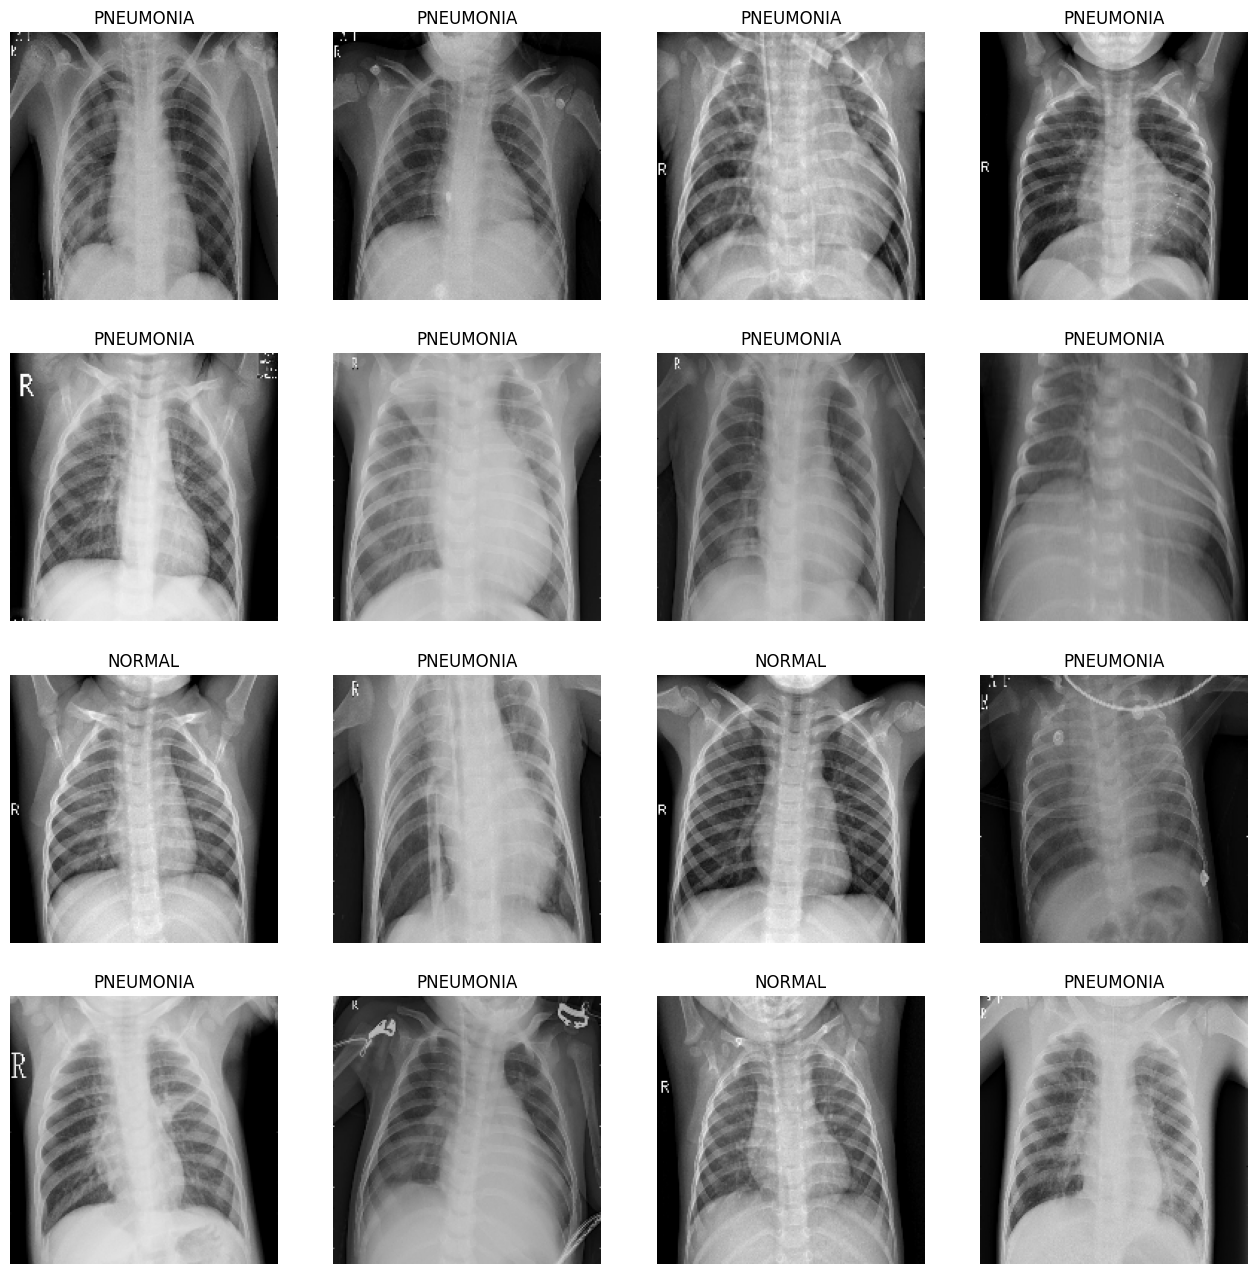

In [ ]:
show_batch(image_batch.numpy(), label_batch.numpy())

## Criando o seu modelo CNN

O modelo terá alguns blocos de componentes CNN (convolução mais pooling e dropout). Após os blocos de CNN, vamos adicionar a parte fully-connected, com algumas camadas do tipo `Dense`.

In [ ]:
model = keras.Sequential(
    layers=[
        layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),

        # Preprocessing como camada do Keras
        layers.Rescaling(1.0 / 255),

        # Conv layers
        layers.Conv2D(16, 3, activation="relu", padding="same"),
        layers.MaxPool2D(),
        layers.Dropout(0.2),

        layers.Conv2D(32, 3, activation="relu", padding="valid"),
        layers.MaxPool2D(),
        layers.Dropout(0.2),

        layers.Conv2D(64, 3, activation="relu", padding="valid"),
        layers.MaxPool2D(),
        layers.Dropout(0.2),

        # Fully-connected
        # Ajusta neurônios em um array
        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),

        # Mais um layer fully connected
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),

        # Output: classificação binária
        layers.Dense(1, activation="sigmoid"),
    ],
    name="pneumo_convnet",
)

model.summary()

Model: "pneumo_convnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 88, 88, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 44, 44, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 44, 44, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 42, 42, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 21, 21, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 21, 21, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 28224)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       7,225,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,286,241 (27.79 MB)

 Trainable params: 7,286,241 (27.79 MB)

 Non-trainable params: 0 (0.00 B)

São mais de sete milhões de parâmetros do modelo.

## Treinando o modelo

Como classificação binária, vamos registrar as seguintes métricas de desempenho:

- Precision
- Recall
- Accuracy

A função de perda será a `binary crossentropy loss`.

In [ ]:
METRICS = [
  keras.metrics.BinaryAccuracy(),
  keras.metrics.Precision(name="precision"),
  keras.metrics.Recall(name="recall"),
]

model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=0.001),
  loss="binary_crossentropy",
  metrics=METRICS,
)

In [ ]:
%%time
history = model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
)

Epoch 1/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - binary_accuracy: 0.7772 - loss: 0.4821 - precision: 0.8037 - recall: 0.9255 - val_binary_accuracy: 0.9554 - val_loss: 0.1361 - val_precision: 0.9652 - val_recall: 0.9752
Epoch 2/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - binary_accuracy: 0.9452 - loss: 0.1434 - precision: 0.9605 - recall: 0.9661 - val_binary_accuracy: 0.9632 - val_loss: 0.1182 - val_precision: 0.9596 - val_recall: 0.9922
Epoch 3/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - binary_accuracy: 0.9620 - loss: 0.1090 - precision: 0.9755 - recall: 0.9734 - val_binary_accuracy: 0.9748 - val_loss: 0.0717 - val_precision: 0.9907 - val_recall: 0.9752
Epoch 4/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - binary_accuracy: 0.9678 - loss: 0.0827 - precision: 0.9782 - recall: 0.9786 - val_binary_accuracy: 0.9797 - val_loss: 0.0594 - val_precision: 0.9844 - val_recall: 0.9883
Epoch 5/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - binary_accuracy: 0.9779 - loss: 0.0602 - pre

## Visualizando o desempenho

Atenção: os números podem mudar em cada rodada devido a fatores aleatórios e probabilísticos dos modelos.

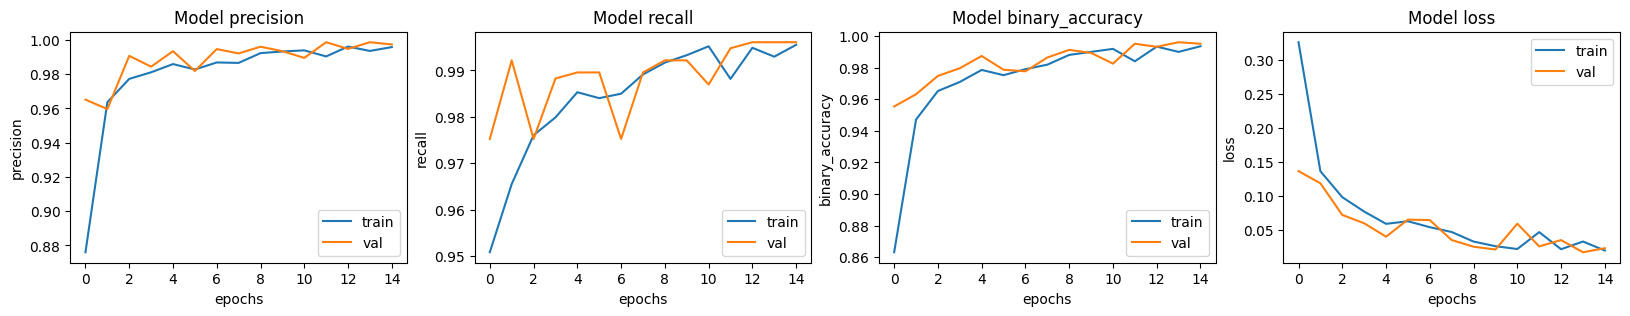

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(20, 3))
ax = ax.ravel()

for i, met in enumerate(["precision", "recall", "binary_accuracy", "loss"]):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history["val_" + met])
    ax[i].set_title("Model {}".format(met))
    ax[i].set_xlabel("epochs")
    ax[i].set_ylabel(met)
    ax[i].legend(["train", "val"])

Sua análise: O modelo apresenta recall muito alto, indicando que consegue identificar quase todos os casos de pneumonia, porém com precisão e acurácia mais baixas, sugerindo presença de muitos falsos positivos. Isso é comum em problemas médicos, onde priorizar recall é desejável, mas o modelo ainda pode ser melhor ajustado para reduzir erros.

## Avaliando o modelo

In [ ]:
model.evaluate(test_ds, return_dict=True)

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - binary_accuracy: 0.4901 - loss: 6.7667 - precision: 0.3340 - recall: 0.6507


{'binary_accuracy': 0.7339743375778198,
 'loss': 3.5790247917175293,
 'precision': 0.7028985619544983,
 'recall': 0.9948717951774597}

Sua análise: O modelo apresenta recall extremamente alto, indicando excelente capacidade de identificar casos de pneumonia (baixo falso negativo), o que é desejável em aplicações médicas. Entretanto, a precisão moderada e a perda elevada indicam maior taxa de falsos positivos, sugerindo que o modelo tende a superestimar a classe pneumonia.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
This image is 0.62 percent NORMAL
This image is 99.38 percent PNEUMONIA


<ipython-input-14-d4c28b2be0ce>:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("This image is %.2f percent %s" % ((100 * score), name))


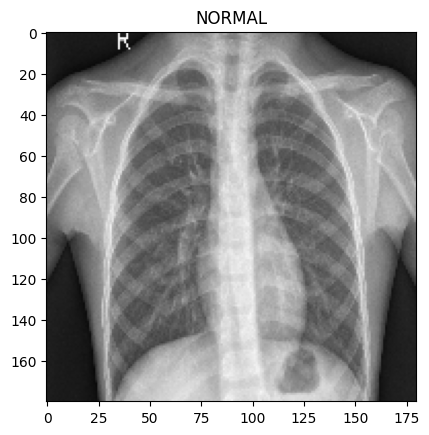

In [ ]:
for image, label in test_ds.take(1):
    plt.imshow(image[0] / 255.0)
    plt.title(CLASS_NAMES[label[0].numpy()])

prediction = model.predict(test_ds.take(1))[0]
scores = [1 - prediction, prediction]

for score, name in zip(scores, CLASS_NAMES):
    print("This image is %.2f percent %s" % ((100 * score), name))

# Desafio: Data Augmentation

Modifique as camadas do modelo para utilizar [camadas de data augmentation do keras](https://keras.io/api/layers/preprocessing_layers/image_augmentation/). Para esse exercício, utilize as camadas:

- `RandomContrast`
- `RandomBrightness`

> Para pensar: por que não utilizar camadas de rotação e recorte?

Faça a alteração do modelo e compare os resultados.